In [192]:
import cv2
import matplotlib.pyplot as plt
import numpy as np 

import os
import re
import ast

P=plt.plot
PS=plt.show

cv2.__version__

### glo_ start ###
def fun_hist(img_c, pick):
    hist_ = [0]*256
    for e in img_c:
        hist_[e]+=1
    P(hist_[pick:])
    PS()    
    return hist_

def fun_img_proc(fn_rgb):
    img_rgb = cv2.imread(fn_rgb, cv2.IMREAD_UNCHANGED)
    rows = img_rgb.shape[0]
    cols = img_rgb.shape[1]
    chn = img_rgb.shape[2]
    
    b = img_rgb[:,:,0].flatten()
    g = img_rgb[:,:,1].flatten()
    r = img_rgb[:,:,2].flatten()
    
    from_idx = 0
    hb=fun_hist(b,from_idx)
    hg=fun_hist(g,from_idx)
    hr=fun_hist(r,from_idx)
    
    a_hb = np.argmax(hb)
    a_hg = np.argmax(hg)
    a_hr = np.argmax(hr)

    print("a_hb:", a_hb, ";", "a_hg:", a_hg, ";", "a_hr:", a_hr, ";" )
    
    
    # show img
    img_rgb = cv2.cvtColor(img_rgb, cv2.COLOR_BGR2RGB) 
    plt.imshow(img_rgb)
    plt.show()

def fun_hist_transform_on_ref(img,imgref):
    histImg, bins = np.histogram(img.flatten(),256)
    histRef, bins = np.histogram(imgref.flatten(),256)
    
    cdfImg = histImg.cumsum();
    cdfRef = histRef.cumsum();
    
    transM = np.zeros(256)
    
    for i in range(256):
        index = 0
        vMin = np.fabs(cdfImg[i] - cdfRef[0])
        for j in range(256):
            diff = np.fabs(cdfImg[i] - cdfRef[j])
            if diff < vMin:
                index = int(j)
                vMin = diff 
        transM[i] = index
    
    imgOut = transM[img].astype(np.uint8)
    fig = plt.figure(figsize=(10,7))
    plt.subplot(131), plt.title("original image"), plt.axis("off")
    plt.imshow(img, cmap='gray')
    
    plt.subplot(132), plt.title("Match template "), plt.axis("off")
    plt.imshow(imgref, cmap='gray')
    
    plt.subplot(133), plt.title("matching output "), plt.axis("off")
    plt.imshow(imgOut, cmap='gray')
    plt.show()    
    return imgOut
    
def fun_s_i(img):
    channels = 1
    rows = img.shape[0]
    cols = img.shape[1]
    if len(img.shape)>2:
        rows, cols, channels = img.shape
    
    cmapv = "gray"
    img_show = img
    
    if channels == 1:
        pass
    if channels == 3:
        imgrgb = img
        img_show = cv2.cvtColor(imgrgb, cv2.COLOR_BGR2RGB) 
        cmapv = "viridis"

 
    plt.imshow(img_show, cmap=cmapv)
    plt.show()

def fun_resize(img, scale_f):
    rows , cols = img.shape[:2]
    img_sc = cv2.resize(img, (int(rows*scale_f),int(cols*scale_f)))
    return img_sc

def fun_read_img(fn):
    img = cv2.imread(fn,cv2.IMREAD_UNCHANGED)
    # img_gray = cv2.cvtColor(imgrgb, cv2.COLOR_BGR2GRAY) 
    # img_gray = cv2.cvtColor(imgrgb, cv2.COLOR_RGB2BGR) 
    return img
def fun_img_chn(img):
    channels = 1
    rows = img.shape[0]
    cols = img.shape[1]
    if len(img.shape)>2:
        rows, cols, channels = img.shape
    return channels
    
def fun_to_gray(img):
    assert(fun_img_chn(img)==3)
    img_gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) 
    return img_gray
    
def fun_to_color(img):
    assert(fun_img_chn(img)== 1)
    img_rgb = cv2.merge((img,img,img))
    return img_rgb
    
def fun_match(img_standard,img_to_convert):
    # img_a is standard
    
    # to gray
    gray_standard = cv2.cvtColor(img_standard, cv2.COLOR_BGR2GRAY)
    gray_to_convert = cv2.cvtColor(img_to_convert, cv2.COLOR_BGR2GRAY)
    
    # sift features
    sift = cv2.SIFT_create()
    kp_standard, des_standard = sift.detectAndCompute(gray_standard, None)
    kp_to_convert, des_to_convert = sift.detectAndCompute(gray_to_convert, None)
    
    # FLANN
    FLANN_INDEX_KDTREE = 1
    index_params = dict(algorithm=FLANN_INDEX_KDTREE, trees=5)
    search_params = dict(checks=50)
    
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    
    # KNN
    matches = flann.knnMatch(des_standard, des_to_convert, k=2)
    
    # filter matches 
    good_matches = []
    for m, n in matches:
        if m.distance < 0.7 * n.distance:
            good_matches.append(m)
    
    # grab matches 
    standard_pts = np.float32([kp_standard[m.queryIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    to_convert_pts = np.float32([kp_to_convert[m.trainIdx].pt for m in good_matches]).reshape(-1, 1, 2)
    
    # calculate matrix 
    M, mask = cv2.findHomography(to_convert_pts, standard_pts, cv2.RANSAC)

    disp(M)
    
    # applay to image need fix 
    h, w, _ = img_standard.shape
    img_converted = cv2.warpPerspective(img_to_convert, M, (w, h))

    return img_converted, M
       


# file opt
def fun_read_file(fn):
    assert os.path.isfile(fn), f"file {fn} does not exist"
    with open(fn, "r") as fp:
        return fp.readlines()
    
def fun_parse_eline_img_contour(line):
    parts = line.split(';')
    img = parts[0].strip()
    start_end = ast.literal_eval(parts[1].strip())
    start, end = start_end[0], start_end[1]
    braces = re.findall(r"\{.*?\}", line)
    arr_cell = []
    for b in braces:
        s = b.strip("{}")
        type_val, _ = s.split(",", 1)
        type_val = int(type_val.strip())
        points = re.findall(r"\[[^\[\]]+\]", s)
        pointset = [ast.literal_eval(p) for p in points]
        arr_cell.append({"type": type_val, "pt": pointset})
    return {
        "img": img,
        "start": start,
        "end": end,
        "arr_cell": arr_cell
    }


def fun_parse_eline_img_contour(line):
    parts = line.split(';')
    img = parts[0].strip()
    start_end = ast.literal_eval(parts[1].strip())
    start, end = start_end[0], start_end[1]
    braces = re.findall(r"\{.*?\}", line)
    arr_cell = []
    for b in braces:
        s = b.strip("{}")
        type_val, _ = s.split(",", 1)
        type_val = int(type_val.strip())
        points = re.findall(r"\[[^\[\]]+\]", s)
        pointset = [ast.literal_eval(p) for p in points]
        arr_cell.append({"type": type_val, "pt": pointset})
    return {
        "img": img,
        "start": start,
        "end": end,
        "arr_cell": arr_cell
    }

def move_crop_into_image(x1, y1, crop_size, w, h):
    x2 = x1 + crop_size
    y2 = y1 + crop_size
    if x1 < 0:
        x1 = 0
        x2 = crop_size
    if y1 < 0:
        y1 = 0
        y2 = crop_size
    if x2 > w:
        x2 = w
        x1 = w - crop_size
    if y2 > h:
        y2 = h
        y1 = h - crop_size
    # ensure still valid
    x1 = max(0, min(x1, w - crop_size))
    y1 = max(0, min(y1, h - crop_size))
    x2 = x1 + crop_size
    y2 = y1 + crop_size
    return x1, y1, x2, y2

def fun_mkdir_p(directory_path):
    """Create directory if it doesn't exist"""
    if not os.path.exists(directory_path):
        os.makedirs(directory_path)
        
def crop_cell_and_mask(parsed, viewimg_dir, out_img_dir, out_mask_dir, crop_size=160):
    img_path = viewimg_dir + "/" + parsed["img"]
    img = cv2.imread(img_path)
    if img is None:
        raise FileNotFoundError(f"Cannot open {img_path}")
    h, w = img.shape[:2]
    list_img = []
    list_mask = []

    for idx, cell in enumerate(parsed["arr_cell"]):
        pts = np.array(cell["pt"], dtype=np.int32)
        x, y, bw, bh = cv2.boundingRect(pts)
        cx, cy = x + bw // 2, y + bh // 2
        half = crop_size // 2
        x1 = cx - half
        y1 = cy - half

        x1, y1, x2, y2 = move_crop_into_image(x1, y1, crop_size, w, h)
        crop_img = img[y1:y2, x1:x2]

        mask = np.zeros((h, w), dtype=np.uint8)
        cv2.fillPoly(mask, [pts], 255)
        crop_mask = mask[y1:y2, x1:x2]

        base = os.path.splitext(os.path.basename(img_path))[0]
        
        fun_mkdir_p(out_img_dir)
        fun_mkdir_p(out_mask_dir)
        
        out_img_path = os.path.join(out_img_dir, f"{base}_cell_{idx+1}.png")
        out_mask_path = os.path.join(out_mask_dir, f"{base}_cell_{idx+1}_mask.png")

        cv2.imwrite(out_img_path, crop_img)
        cv2.imwrite(out_mask_path, crop_mask)
        
#         if "08_08" in out_img_path:
#             print(out_img_path)
#             print(out_mask_path)

           
        list_img.append(out_img_path)
        list_mask.append(out_mask_path)
    return list_img, list_mask
        

        



def fun_make_mask(parsed,src_folder, save_folder):
    img_path = src_folder + "/" + parsed["img"]
    img = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
    if img is None:
        raise FileNotFoundError(f"Cannot open {img_path}")
    h, w = img.shape
    mask = np.zeros((h, w), dtype=np.uint8)
    for cell in parsed["arr_cell"]:
        ctype = cell["type"]
        if ctype < 1 or ctype > 4:
            continue
        value = 255
        pts = np.array([cell["pt"]], dtype=np.int32)
        cv2.fillPoly(mask, pts, value)
    # Generate output filename
    img_base = os.path.splitext(os.path.basename(img_path))[0]
    fn_mask = os.path.join(save_folder, f"{img_base}_mask.png")
    cv2.imwrite(fn_mask, mask)
    return img_path, fn_mask

def si(img_path):
    img = fun_read_img(img_path)
    fun_s_i(img)
    
print("env ok")
!date




env ok
Tue Jul 22 15:43:06 CST 2025


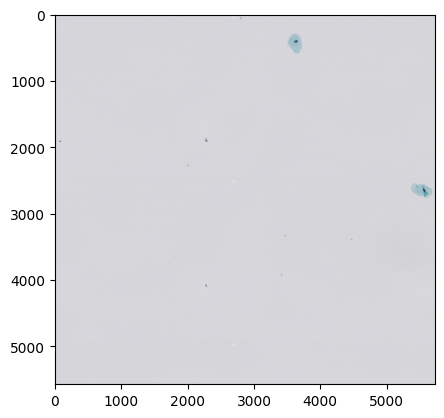

/home/jd/t/data/tilejpg/imgs/00_04_cell_1_crop.png
/home/jd/t/data/tilejpg/masks/00_04_cell_1_mask.png
/home/jd/t/data/tilejpg/imgs/00_04_cell_1_crop.png /home/jd/t/data/tilejpg/masks/00_04_cell_1_mask.png


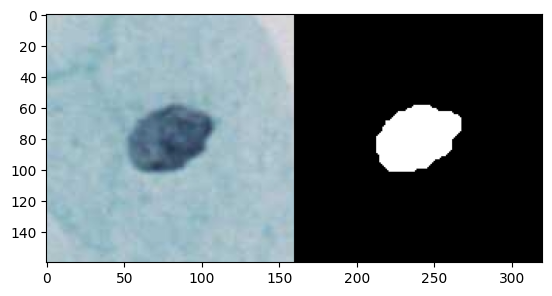

In [2]:
# single thread version 
fn_d="/home/jd/t/data/tilejpg"
fn_list_txt=fn_d+"/" + "fn_list.merge.txt"
arr_fc = fun_read_file(fn_list_txt)
arr_fc = arr_fc[1:]  # strip header

eline = arr_fc[2]


for eline in arr_fc:
    ejson = fun_parse_eline_img_contour(eline)

    img = fun_read_img(fn_d + "/" + ejson["img"])
    fun_s_i(img)

    # print (ejson)

    p_img, p_mask = crop_cell_and_mask(ejson,fn_d,  fn_d + "/imgs", fn_d + "/masks")

    for ei, em in zip(p_img, p_mask):
        print(ei, em)
        img_all = cv2.hconcat([fun_read_img(ei), fun_to_color(fun_read_img(em))])
        fun_s_i(img_all)
    break
    # print (p_img, p_mask)






In [193]:
# multiple thread version 
from concurrent.futures import ThreadPoolExecutor, as_completed
fn_d="/home/jd/t/data/tilejpg"
fn_list_txt=fn_d+"/" + "fn_list.merge.txt"
arr_fc = fun_read_file(fn_list_txt)
arr_fc = arr_fc[1:]  # strip header


print ("BEGIN")
def process_eline(eline, fn_d):
    ejson = fun_parse_eline_img_contour(eline)
    imgpath = fn_d + "/" + ejson["img"]
    if "08_08" in imgpath:
        print(imgpath)
    
#     img = fun_read_img(fn_d + "/" + ejson["img"])
#     fun_s_i(img)
    p_img, p_mask = crop_cell_and_mask(ejson, fn_d, fn_d + "/imgs", fn_d + "/masks")
    return list(zip(p_img, p_mask))

# 并行处理
with ThreadPoolExecutor() as executor:
    futures = [executor.submit(process_eline, eline, fn_d) for eline in arr_fc]
    for future in as_completed(futures):
        for eimg, emask in future.result():
            if "cell_333" in eimg:
                print(eimg, emask)
#             img_all = cv2.hconcat([fun_read_img(ei), fun_to_color(fun_read_img(em))])
#             fun_s_i(img_all)

print("END")

BEGIN
/home/jd/t/data/tilejpg/imgs/DTP2504103_01_07_cell_333.png /home/jd/t/data/tilejpg/masks/DTP2504103_01_07_cell_333_mask.png
/home/jd/t/data/tilejpg/imgs/DTP2504103_03_07_cell_333.png /home/jd/t/data/tilejpg/masks/DTP2504103_03_07_cell_333_mask.png
/home/jd/t/data/tilejpg/imgs/DTP2504103_02_04_cell_333.png /home/jd/t/data/tilejpg/masks/DTP2504103_02_04_cell_333_mask.png
/home/jd/t/data/tilejpg/DTP2504103_08_08.jpg
/home/jd/t/data/tilejpg/imgs/DTP2504103_05_06_cell_333.png /home/jd/t/data/tilejpg/masks/DTP2504103_05_06_cell_333_mask.png
/home/jd/t/data/tilejpg/imgs/DTP2504103_06_06_cell_333.png /home/jd/t/data/tilejpg/masks/DTP2504103_06_06_cell_333_mask.png
/home/jd/t/data/tilejpg/imgs/DTP2504103_06_03_cell_333.png /home/jd/t/data/tilejpg/masks/DTP2504103_06_03_cell_333_mask.png
/home/jd/t/data/tilejpg/imgs/DTP2504103_06_04_cell_333.png /home/jd/t/data/tilejpg/masks/DTP2504103_06_04_cell_333_mask.png
/home/jd/t/data/tilejpg/imgs/DTP2504103_06_05_cell_333.png /home/jd/t/data/tilejp

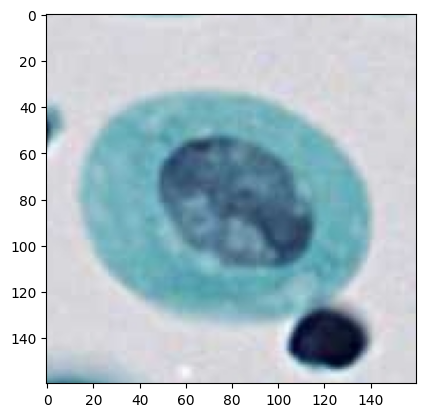

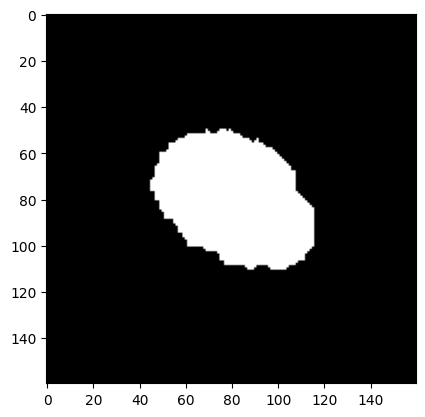

In [194]:
si("/home/jd/t/data/tilejpg/imgs/DTP2504103_13_08_cell_333.png")
si("/home/jd/t/data/tilejpg/masks/DTP2504103_13_08_cell_333_mask.png")


In [119]:
from PIL import Image
from os.path import splitext, isfile, join


def load_image(filename):
    ext = splitext(filename)[1]
    if ext == '.npy':
        return Image.fromarray(np.load(filename))
    elif ext in ['.pt', '.pth']:
        return Image.fromarray(torch.load(filename).numpy())
    else:
        return Image.open(filename)
    
fn = "/home/jd/t/Pytorch-UNet-master/data/masks/08_08_mask.png"
img = load_image(fn)

np_img = np.asarray(img)

print (np_img.ndim)
np.unique(np_img)



3


array([  0, 255], dtype=uint8)

In [25]:
!python /home/jd/t/Pytorch-UNet-master/predict.py -s 0.44  -i /home/jd/t/Pytorch-UNet-master/data/imgs/08_08.jpg --model /home/jd/t/Pytorch-UNet-master/checkpoints/checkpoint_epoch1.pth
!echo END


INFO: Loading model /home/jd/t/Pytorch-UNet-master/checkpoints/checkpoint_epoch1.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image /home/jd/t/Pytorch-UNet-master/data/imgs/08_08.jpg ...
INFO: Mask saved to /home/jd/t/Pytorch-UNet-master/data/imgs/08_08_OUT.png
END


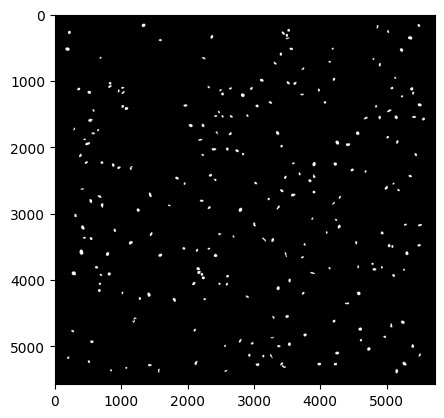

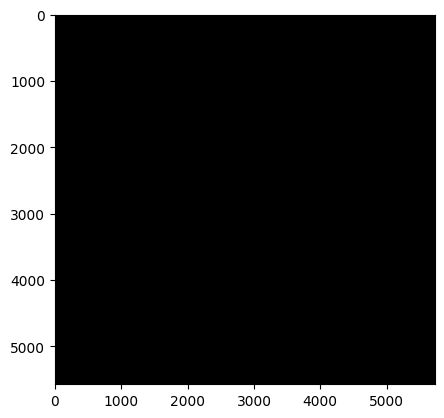

In [26]:
fn = "/home/jd/t/Pytorch-UNet-master/data/masks/08_08_mask.png"
img = fun_read_img(fn)
fun_s_i(img)

# a=(img[1000,:])
# for i in a:
#     if i != 0:
#         print (i)

import shutil
import os

src = '/home/jd/t/Pytorch-UNet-master/data/imgs/08_08_OUT.png'
dst = '/home/jd/t/08_08_OUT.png'

if os.path.exists(src):
    shutil.move(src, dst)
else:
    print(f"Source file does not exist: {src}")

fn = "/home/jd/t/08_08_OUT.png"
img = fun_read_img(fn)
fun_s_i(img)

./car1_OUT.png


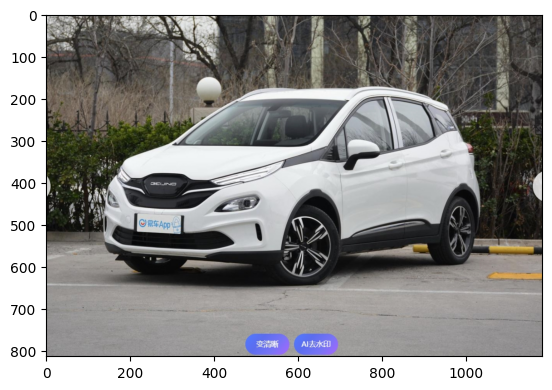

INFO: Loading model /home/jd/t/unet_carvana_scale1.0_epoch2.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image car1.jpg ...
INFO: Mask saved to car1_OUT.png
INFO: Visualizing results for image car1.jpg, close to continue...
Figure(640x480)


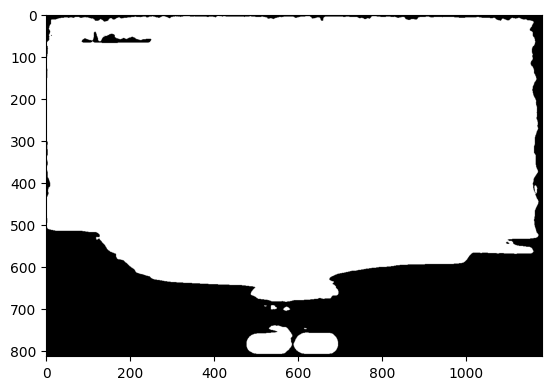

In [13]:
import os
def rename_to_png_with_out(filename):
    base, _ = os.path.splitext(filename)
    new_name = f"{base}_OUT.png"
#     os.rename(filename, new_name)

    print (new_name)
    return new_name

fn = "./car1.jpg"
fn_out = rename_to_png_with_out(fn)




img = fun_read_img(fn)
fun_s_i(img)
!python /home/jd/t/unet/predict.py  -i car1.jpg --model /home/jd/t/unet_carvana_scale1.0_epoch2.pth  --viz
img_out = fun_read_img(fn_out)
fun_s_i(img_out)







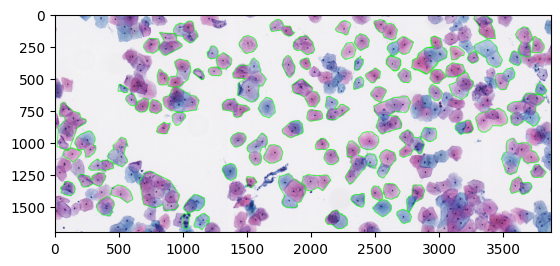

write: /home/jd/t/pulldata/v/20241118001_21_08_mask.png


In [46]:
#serial version 
import cv2
import numpy as np
import json

def draw_cells_mask(json_path, img_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    out_path = img_path.replace(".jpg", "_mask.png")
    c = 3
    d = 255/(c-1)
    arr_celltype = ["单个细胞","成团细胞"]
    celltype_s = arr_celltype[0]
    celltype_t = arr_celltype[1]
    
    for cell in data:
        pts = np.array([[p["x"], p["y"]] for p in cell["points"]], dtype=np.int32).reshape((-1,1,2))
        
        if cell["cellType"] == celltype_t:
            cv2.fillPoly(mask, [pts], color=d*1)
        elif cell["cellType"] == celltype_s:
             cv2.fillPoly(mask, [pts], color=d*2)

#     cv2.imwrite(out_path, mask)
    return mask,out_path

def draw_cells(json_path, img_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    img = cv2.imread(img_path)
    for cell in data:
        pts = np.array([[p["x"], p["y"]] for p in cell["points"]], dtype=np.int32).reshape((-1,1,2))
        cv2.polylines(img, [pts], isClosed=True, color=(0,255,0), thickness=4)
    return img

def proc_e_json_jpg(barcode):
#     barcode = "20250411013_18_07"
    json_path =  "/home/jd/t/pulldata/v/" + barcode + ".json"
    jpg_path = "/home/jd/t/pulldata/v/" + barcode + ".jpg"

    img = draw_cells(json_path, jpg_path)
    fun_s_i(img)
    mask, mask_path = draw_cells_mask(json_path, jpg_path)
#     cv2.imwrite(jpg_path+".new.jpg", img)
#     cv2.imwrite(mask_path, mask)

#     fun_s_i(mask)
    print("write:" ,mask_path)
#     print(mask.shape)
    
# arr_barcode = [ "20241223005_04_08", "20241223005_06_09", "20241223005_25_08", "20241223005_26_04", "20241223005_02_04", "20241223005_26_06", "20241223005_24_08", "20241223005_04_04", "20241223005_23_03", "20241223005_07_05", "20241223005_24_07", "20241223005_07_04", "20241223005_27_05", "20241223005_14_02", "20241223005_25_05" ]    

folder = "/home/jd/t/pulldata/v/"
arr_barcode = [
    f[:-5]
    for f in os.listdir(folder)
    if f.endswith('.json')
]
# print(arr_barcode)

for ebarcode in arr_barcode:
    proc_e_json_jpg(ebarcode)
    break


In [69]:
import cv2
import numpy as np
import json
import os
from concurrent.futures import ThreadPoolExecutor

def draw_cells_mask(json_path, img_path, celltype):
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    out_path = img_path.replace(".jpg", "_mask.png")
    c = 3
    d = 255/(c-1)
    arr_celltype = ["单个细胞","成团细胞"]
    celltype_cell = arr_celltype[0]
    celltype_cluster = arr_celltype[1]
    
    if celltype == "cell":
        for cell in data:
            pts = np.array([[p["x"], p["y"]] for p in cell["points"]], dtype=np.int32).reshape((-1,1,2))
            if cell["cellType"] == celltype_cell:
                cv2.fillPoly(mask, [pts], color=255)
    
    if celltype == "cluster":
        for cell in data:
            pts = np.array([[p["x"], p["y"]] for p in cell["points"]], dtype=np.int32).reshape((-1,1,2))
            if cell["cellType"] == celltype_cluster:
                cv2.fillPoly(mask, [pts], color=255)    


#     cv2.imwrite(out_path, mask)
    return mask,out_path

def draw_cells_mask_all(json_path, img_path):
    
    with open(json_path, 'r') as f:
        data = json.load(f)
    img = cv2.imread(img_path)
    h, w = img.shape[:2]
    mask = np.zeros((h, w), dtype=np.uint8)
    out_path = img_path.replace(".jpg", "_mask.png")
    c = 3
    d = 255/(c-1)
    arr_celltype = ["单个细胞","成团细胞"]
    celltype_cell = arr_celltype[0]
    celltype_cluster = arr_celltype[1]
    
    
    for cell in data:
        pts = np.array([[p["x"], p["y"]] for p in cell["points"]], dtype=np.int32).reshape((-1,1,2))
        if cell["cellType"] == celltype_cell:
            cv2.fillPoly(mask, [pts], color=d*1)


    for cell in data:
        pts = np.array([[p["x"], p["y"]] for p in cell["points"]], dtype=np.int32).reshape((-1,1,2))
        if cell["cellType"] == celltype_cluster:
            cv2.fillPoly(mask, [pts], color=d*2)    


#     cv2.imwrite(out_path, mask)
    return mask,out_path


def draw_cells(json_path, img_path):
    with open(json_path, 'r') as f:
        data = json.load(f)
    img = cv2.imread(img_path)
    for cell in data:
        pts = np.array([[p["x"], p["y"]] for p in cell["points"]], dtype=np.int32).reshape((-1,1,2))
        cv2.polylines(img, [pts], isClosed=True, color=(0,255,0), thickness=4)
    return img

def proc_e_json_jpg_to_mask_all(barcode, folder_in):
    json_path = os.path.join(folder_in, barcode + ".json")
    jpg_path = os.path.join(folder_in, barcode + ".jpg")
#     img = draw_cells(json_path, jpg_path)
#     mask, mask_path = draw_cells_mask(json_path, jpg_path, celltype)
    mask, mask_path = draw_cells_mask_all(json_path, jpg_path)
#     cv2.imwrite(jpg_path + ".new.jpg", img)
    if "08_08" in mask_path:
        print("write:", mask_path)
    cv2.imwrite(mask_path, mask)

def proc_e_json_jpg_to_mask(barcode, folder_in, celltype):
    json_path = os.path.join(folder_in, barcode + ".json")
    jpg_path = os.path.join(folder_in, barcode + ".jpg")
#     img = draw_cells(json_path, jpg_path)
    mask, mask_path = draw_cells_mask(json_path, jpg_path, celltype)
#     mask, mask_path = draw_cells_mask_all(json_path, jpg_path)
#     cv2.imwrite(jpg_path + ".new.jpg", img)
    if "08_08" in mask_path:
        print("write:", mask_path)
    cv2.imwrite(mask_path, mask)

#     print(mask.shape)

    
# main_    
folder = "/home/jd/t/pulldata/v"

arr_barcode = [
    f[:-5]
    for f in os.listdir(folder)
    if f.endswith('.json')
]

folders = [folder] * len(arr_barcode)
# celltypes = ["cell"] * len(arr_barcode)
celltypes = ["cluster"] * len(arr_barcode)


with ThreadPoolExecutor() as executor:
#     executor.map(proc_e_json_jpg_to_mask, arr_barcode, folders, celltypes)
    executor.map(proc_e_json_jpg_to_mask_all, arr_barcode, folders)

print("END")


write: /home/jd/t/pulldata/v/20241223005_08_08_mask.png
write: /home/jd/t/pulldata/v/20241118001_08_08_mask.png
write: /home/jd/t/pulldata/v/20241210007_08_08_mask.png
END


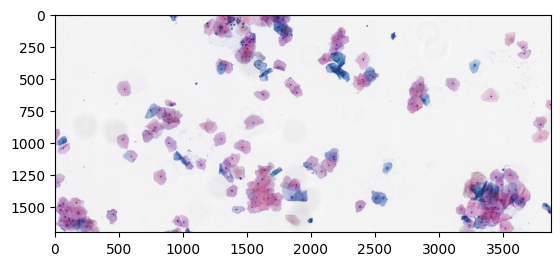

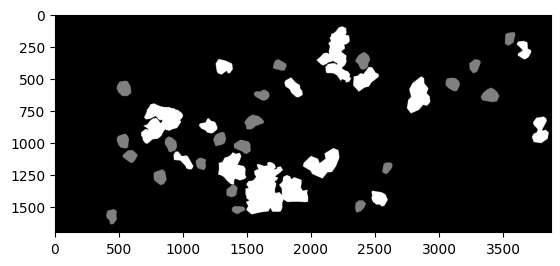

In [71]:
"""
/home/jd/t/pulldata/v/20241223005_08_08.jpg
/home/jd/t/pulldata/v/20241210007_08_08.jpg
/home/jd/t/pulldata/v/cell/20241223005_08_08_mask.png
/home/jd/t/pulldata/v/cell/20241118001_08_08_mask.png
/home/jd/t/pulldata/v/cell/20241210007_08_08_mask.png
/home/jd/t/pulldata/v/cluster/20241223005_08_08_mask.png
/home/jd/t/pulldata/v/cluster/20241118001_08_08_mask.png
/home/jd/t/pulldata/v/cluster/20241210007_08_08_mask.png
"""

si("/home/jd/t/pulldata/v/20241223005_08_08.jpg")
si("/home/jd/t/pulldata/v/20241223005_08_08_mask.png")
# si("/home/jd/t/pulldata/v/cluster/20241223005_08_08_mask.png")


In [53]:
!python /home/jd/t/Pytorch-UNet-master/predict.py -s 0.5 --classes 3  --model /home/jd/t/Pytorch-UNet-master/checkpoints/checkpoint_epoch6.pth -i /home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/20241118001_08_09.jpg --viz


INFO: Loading model /home/jd/t/Pytorch-UNet-master/checkpoints/checkpoint_epoch6.pth
INFO: Using device cuda
INFO: Model loaded!
INFO: Predicting image /home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/20241118001_08_09.jpg ...
INFO: Mask saved to /home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/20241118001_08_09_OUT.png
INFO: Visualizing results for image /home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/20241118001_08_09.jpg, close to continue...
Figure(640x480)


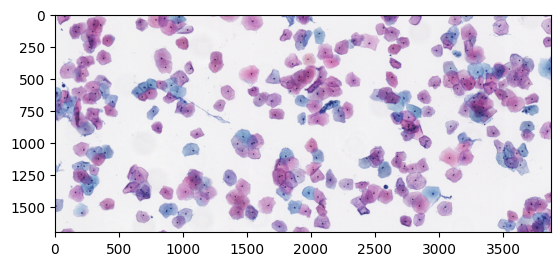

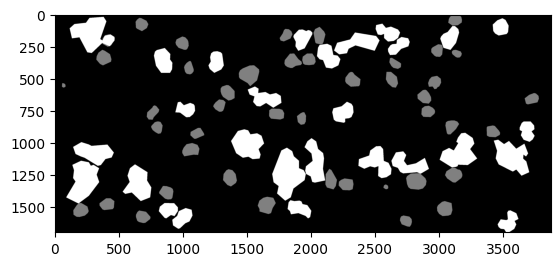

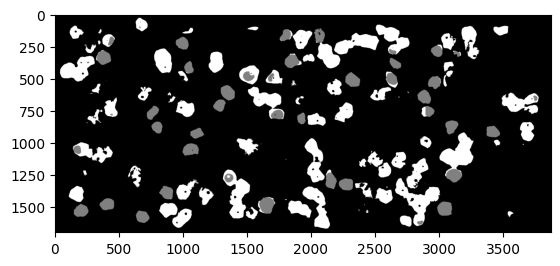

In [74]:
si("/home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/20241118001_08_09.jpg")
si("/home/jd/t/Pytorch-UNet-master/data/cyto/infer/masks/20241118001_08_09_mask.png")
si("/home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/20241118001_08_09_OUT.png")


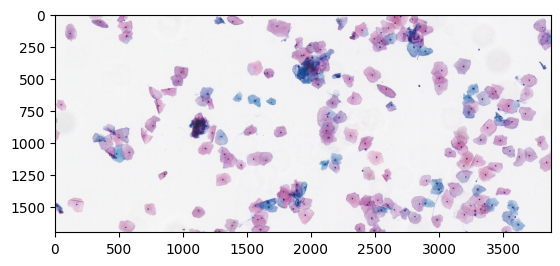

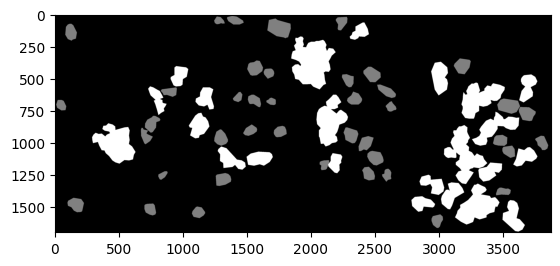

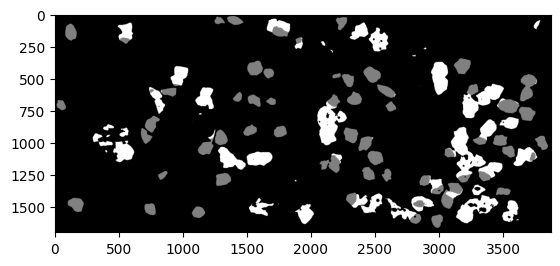

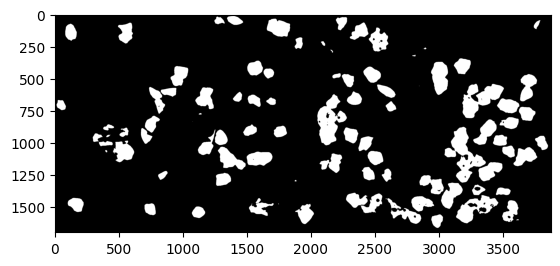

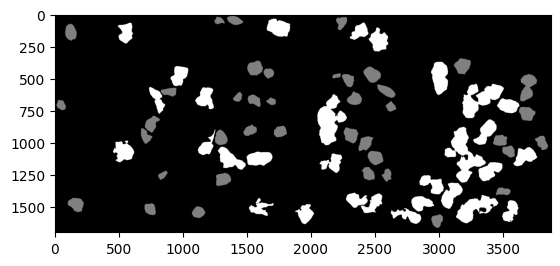

In [117]:
import cv2
import numpy as np

def binarize(img, threshold=25):
    _, bin_img = cv2.threshold(img, threshold, 255, cv2.THRESH_BINARY)
    return bin_img

def fill_holes(bin_img):
    inv_bin = cv2.bitwise_not(bin_img)
    h, w = bin_img.shape
    mask = np.zeros((h + 2, w + 2), np.uint8)
    cv2.floodFill(inv_bin, mask, (0, 0), 255)
    inv_filled = cv2.bitwise_not(inv_bin)
    filled = cv2.bitwise_or(bin_img, inv_filled)
    return filled

def find_non_overlapping_contours(bin_img):
    contours, hierarchy = cv2.findContours(bin_img, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    return contours

def split_contours_by_value(img_r0, contours):
    vector_cell = []
    vector_cluster = []
    idx  = 0
    for cnt in contours:
        mask = np.zeros(img_r0.shape, np.uint8)
        cv2.drawContours(mask, [cnt], -1, 255, thickness=cv2.FILLED)
        # Get all points inside contour
        points = np.where(mask == 255)
        values = img_r0[points]
        
#         if len(points[0]) > 0 and points[1][0] < 250 and points[0][0] > 1250:
#             fun_s_i(mask)
#             print(idx)
#             a = img_r0[points]
            
            
#             for ep in a:
#                 if ep == 128:
#                     pass
#                 else: 
#                     print (ep)
            
            
   # Calculate the ratio of pixels with value <= 129
        if len(values) == 0:
            continue
        ratio = np.sum(values <= 129) / len(values)
        if ratio >= 0.95:
            vector_cell.append(cnt)
        else:
            vector_cluster.append(cnt)
        idx += 1
        
    return vector_cell, vector_cluster

def calc_median_area(contours):
    """
    Calculate the median area of contours.
    :param contours: List of contours (vector_cell).
    :return: Median area (float).
    """
    if not contours:
        return 0.0
    areas = [cv2.contourArea(cnt) for cnt in contours]
    return float(np.median(areas))

def filter_contours_by_area(contours, min_area):
    """
    Filter contours by minimum area.
    :param contours: List of contours (vector_cluster).
    :param min_area: Area threshold.
    :return: Filtered list of contours.
    """
    filtered = [cnt for cnt in contours if cv2.contourArea(cnt) >= min_area]
    return filtered

def main():
    arr_view_id = ["20241118001_08_09","20241210007_08_09", "20241223005_08_09" ]
    
    ######################
    view_id = arr_view_id[2]
    ######################
    
    
    si("/home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/"+ view_id + ".jpg")
    si("/home/jd/t/Pytorch-UNet-master/data/cyto/infer/masks/" + view_id + "_mask.png")


    img_r0 = cv2.imread('/home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/' + view_id + '_OUT.png', cv2.IMREAD_GRAYSCALE)
    
    fun_s_i(img_r0)
    if img_r0 is None:
        print("Input image not found.")
        return

    bin_img = binarize(img_r0, threshold=25)
    filled_img = fill_holes(bin_img)
    fun_s_i(filled_img)
    contours = find_non_overlapping_contours(filled_img)
#     black_bg = np.zeros_like(img_r0)
#     cv2.drawContours(black_bg, contours, -1, color=255, thickness=cv2.FILLED)
#     fun_s_i(black_bg)
    
    vector_cell, vector_cluster = split_contours_by_value(img_r0, contours)

    area_median = calc_median_area(vector_cell)
    vector_cluster = filter_contours_by_area(vector_cluster, area_median*1.5)
    
    black_bg = np.zeros_like(img_r0)
    if vector_cell:
        cv2.drawContours(black_bg, vector_cell, -1, color=128, thickness=cv2.FILLED)
    if vector_cluster:
        cv2.drawContours(black_bg, vector_cluster, -1, color=255, thickness=cv2.FILLED)
        

#     # Create black background and fill contours as white
#     black_bg = np.zeros_like(img_r0)
#     cv2.drawContours(black_bg, contours, -1, color=255, thickness=cv2.FILLED)
    fun_s_i(black_bg)
    cv2.imwrite('/home/jd/t/Pytorch-UNet-master/data/cyto/infer/imgs/' + view_id + '_OUT2.png', black_bg)
#     fun_s_i(img_r0)

if __name__ == "__main__":
    main()

['DTP2504103_08_09_cell_226.png', 'DTP2504073_08_09_cell_33.png', 'DTP2504103_08_09_cell_221.png', 'DTP2504103_08_09_cell_229.png', 'DTP2504103_08_09_cell_222.png', 'DTP2504092_08_09_cell_233.png', 'DTP2504103_08_09_cell_225.png', 'DTP2504103_08_09_cell_22.png', 'DTP2504103_08_09_cell_122.png', 'DTP2504092_08_09_cell_33.png', 'DTP2504103_08_09_cell_223.png', 'DTP2504092_08_09_cell_133.png', 'DTP2504103_08_09_cell_220.png', 'DTP2504073_08_09_cell_133.png', 'DTP2504103_08_09_cell_228.png', 'DTP2504073_08_09_cell_233.png', 'DTP2504103_08_09_cell_227.png', 'DTP2504103_08_09_cell_224.png']


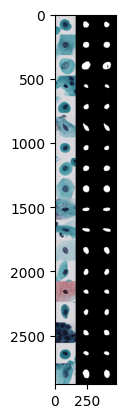

END


In [196]:
folder = "/home/jd/t/Pytorch-UNet-master/data/cell/infer/imgs/"
arr_fn_img = [
    f
    for f in os.listdir(folder)
    if f.endswith('.png') and not "OUT" in f
]

arr_fn_img_OUT = [
    f.replace(".png", "_OUT.png")
    for f in arr_fn_img
]

folder_mask = folder.replace("imgs", "masks")
arr_fn_img_mask = [
    f
    for f in os.listdir(folder_mask)
    if f.endswith('.png') and "_mask" in f
]
print(arr_fn_img)


list_img_all = []
for e_img in arr_fn_img:
    e_img_r0 = e_img
    abs_e_img = folder + e_img
    abs_e_img_out = abs_e_img.replace(".png", "_OUT.png")
    abs_e_img_mask = abs_e_img.replace("imgs", "masks")
    abs_e_img_mask = abs_e_img_mask.replace(".png", "_mask.png")
    
    eimg = fun_read_img(abs_e_img)
    eimg_out = fun_read_img(abs_e_img_out)
    eimg_mask = fun_read_img(abs_e_img_mask)
    
    eimg_out = fun_to_color(eimg_out)
    eimg_mask = fun_to_color(eimg_mask)
    eimg_all = cv2.hconcat([eimg, eimg_mask, eimg_out])
    list_img_all.append(eimg_all)
#     fun_s_i(eimg_all)
    
    
    
eimg_all_h = cv2.vconcat(list_img_all)    

img_save = "/home/jd/t/1.jpg"
cv2.imwrite(img_save, eimg_all_h)

si(img_save)
print("END")
    
    
    




In [168]:
list_a = []
for i in range(9):
    list_a.append(i)
print(list_a)

list_b = [str(i) for i in list_a if i % 2 and ( "1" in str(i) or "3" in str(i)) ]
print (list_b)



[0, 1, 2, 3, 4, 5, 6, 7, 8]
['1', '3']


In [175]:
import onnx
model = onnx.load('/home/jd/t/Pytorch-UNet-master/checkpoints/checkpoint_epoch1.onnx')
print(model)

IOPub data rate exceeded.
The notebook server will temporarily stop sending output
to the client in order to avoid crashing it.
To change this limit, set the config variable
`--NotebookApp.iopub_data_rate_limit`.

Current values:
NotebookApp.iopub_data_rate_limit=1000000.0 (bytes/sec)
NotebookApp.rate_limit_window=3.0 (secs)

